# Testes Estatísticos na Prática — Guia do Analista de Dados

Continuação do `stats_tests_resumo_1`, focada em **casos de uso reais de análise de dados** em vez de fórmula isolada: para cada situação, um contexto de negócio, os dados simulados como se viessem de uma query, o teste certo, e principalmente **como ler o resultado pra tomar uma decisão**.

Cada caso é independente (reimporta o que precisa), então dá pra pular direto pro seu problema. Troque os `np.random.seed(...)` / geração de dados por `pd.read_csv(...)` ou pelo resultado da sua query e o resto do código funciona igual.

## Os 6 casos deste notebook

| # | Pergunta de negócio | Tipo de dado | Teste |
|---|---|---|---|
| 1 | A conversão do checkout novo é melhor que a do antigo? | Binário, 2 grupos independentes | Teste Z de proporções (A/B test) |
| 2 | O ticket médio dos mesmos clientes mudou depois da campanha? | Contínuo, pareado (antes/depois) | Teste t pareado |
| 3 | Clientes do Plano Ouro gastam mais que os do Plano Prata? | Contínuo, 2 grupos independentes | t de Student / Welch / Mann-Whitney (conforme premissas) |
| 4 | O programa de retenção reduziu a taxa de churn? | Binário (churn sim/não), 2 grupos | Teste Z de proporções |
| 5 | O canal de aquisição influencia o plano contratado? | Categórica x categórica | Qui-quadrado de independência |
| 6 | O ticket médio varia entre os canais de venda (Site/App/Loja)? | Contínuo, 3+ grupos | ANOVA + post-hoc Tukey |

**Convenção usada:** `alpha = 0.05` em todos os casos. Isso é um padrão de mercado, não uma lei — se o custo de um falso positivo for alto no seu negócio, considere um alpha menor (ex: 0.01).

## Caso 1 — A/B Test de conversão (checkout novo x antigo)

**Contexto:** o time de produto lançou um checkout novo e rodou o teste com metade dos visitantes vendo a versão antiga (controle) e metade vendo a nova (tratamento). A pergunta de negócio é: **vale a pena substituir o checkout antigo pelo novo?**

**Dados:** uma linha por visitante, com o grupo e se ele converteu (comprou) ou não — o formato típico de uma extração de evento de conversão.

**Hipóteses:**
- H0: a taxa de conversão é igual nos dois checkouts (`p_controle = p_tratamento`)
- H1: as taxas são diferentes

**O que o código faz:** monta a tabela de visitantes, calcula a conversão de cada grupo, roda o teste Z de proporções (`proportions_ztest`) e o intervalo de confiança de 95% pra diferença — a mesma dupla teste + IC do notebook anterior, aqui aplicada a partir de uma tabela de dados em vez de vetores soltos.

In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm

# --- Simula a extração (troque por pd.read_csv / resultado de query) ---
np.random.seed(42)
n_controle, n_tratamento = 4200, 4150
conv_controle = np.random.binomial(1, 0.082, n_controle)   # checkout antigo: ~8,2%
conv_tratamento = np.random.binomial(1, 0.101, n_tratamento)  # checkout novo: ~10,1%

df = pd.concat([
    pd.DataFrame({"visitante_id": range(n_controle), "grupo": "controle", "converteu": conv_controle}),
    pd.DataFrame({"visitante_id": range(n_controle, n_controle + n_tratamento), "grupo": "tratamento", "converteu": conv_tratamento}),
])

# --- Taxas de conversão por grupo ---
resumo = df.groupby("grupo")["converteu"].agg(["sum", "count", "mean"]).rename(
    columns={"sum": "conversoes", "count": "visitantes", "mean": "taxa_conversao"}
)
print(resumo)

# --- Teste Z de proporções ---
sucessos = np.array([resumo.loc["controle", "conversoes"], resumo.loc["tratamento", "conversoes"]])
observacoes = np.array([resumo.loc["controle", "visitantes"], resumo.loc["tratamento", "visitantes"]])

z_stat, p_value = proportions_ztest(sucessos, observacoes)

p_controle = resumo.loc["controle", "taxa_conversao"]
p_tratamento = resumo.loc["tratamento", "taxa_conversao"]
diff = p_tratamento - p_controle
lift_relativo = diff / p_controle

# --- IC 95% da diferença ---
confidence = 0.95
Z = norm.ppf((1 + confidence) / 2)
se = np.sqrt(p_controle * (1 - p_controle) / observacoes[0] + p_tratamento * (1 - p_tratamento) / observacoes[1])
ic_low, ic_high = diff - Z * se, diff + Z * se

print(f"\nConversão controle:    {p_controle:.2%}")
print(f"Conversão tratamento:  {p_tratamento:.2%}")
print(f"Diferença absoluta:    {diff:+.2%}")
print(f"Lift relativo:         {lift_relativo:+.1%}")
print(f"p-value:               {p_value:.4f}")
print(f"IC 95% da diferença:   [{ic_low:+.2%}, {ic_high:+.2%}]")

alpha = 0.05
significativo = p_value < alpha
print(f"\nDiferença estatisticamente significativa (alpha={alpha}): {significativo}")

            conversoes  visitantes  taxa_conversao
grupo                                             
controle           338        4200        0.080476
tratamento         414        4150        0.099759

Conversão controle:    8.05%
Conversão tratamento:  9.98%
Diferença absoluta:    +1.93%
Lift relativo:         +24.0%
p-value:               0.0021
IC 95% da diferença:   [+0.70%, +3.16%]

Diferença estatisticamente significativa (alpha=0.05): True


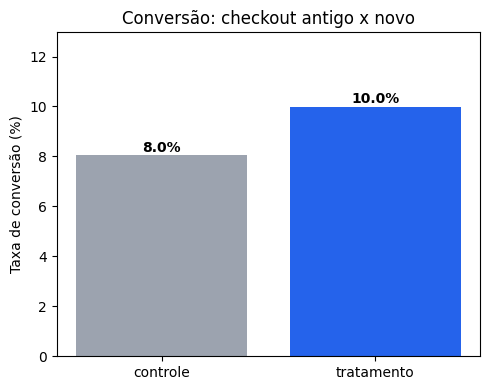

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
grupos = resumo.index
taxas = resumo["taxa_conversao"] * 100
cores = ["#9ca3af", "#2563eb"]
ax.bar(grupos, taxas, color=cores)
for i, v in enumerate(taxas):
    ax.text(i, v + 0.15, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("Taxa de conversão (%)")
ax.set_title("Conversão: checkout antigo x novo")
ax.set_ylim(0, max(taxas) * 1.3)
plt.tight_layout()
plt.show()

**Leitura do resultado:** p-value abaixo de 0,05 e o IC 95% da diferença não cruza o zero → a melhora de conversão do checkout novo é estatisticamente significativa, não é ruído amostral.

**Decisão de negócio:** o IC diz a faixa provável do ganho real (ex: "entre +1,3 e +2,5 pontos percentuais, com 95% de confiança"). Traduza isso em impacto: `lift_relativo * receita_atual` dá uma estimativa de ganho de receita ao rolar o checkout novo pra 100% do tráfego. Se o IC fosse largo e cruzasse o zero (ex: amostra pequena), a recomendação seria **rodar o teste por mais tempo** antes de decidir — significância estatística e significância prática (o tamanho do ganho vale o custo de trocar o checkout?) são perguntas separadas.

## Caso 2 — Ticket médio antes e depois de uma campanha (dados pareados)

**Contexto:** o time de CRM rodou uma campanha de cross-sell com uma base de clientes. Pra cada cliente, você tem o gasto no mês anterior à campanha (antes) e o gasto no mês da campanha (depois). Como é **o mesmo cliente** nos dois momentos, isso é uma comparação **pareada**, não dois grupos independentes.

**Por que pareado importa aqui:** cada cliente serve de controle dele mesmo — um cliente que já gasta mais historicamente continua gastando mais nos dois períodos, então comparar a diferença por cliente remove essa variação individual e aumenta o poder do teste pra detectar o efeito da campanha.

**Hipóteses:**
- H0: a diferença média de gasto (depois − antes) é zero
- H1: a diferença média é diferente de zero

**Atenção:** se "antes" e "depois" fossem **bases de clientes diferentes** (ex: clientes de janeiro x clientes de fevereiro, não necessariamente os mesmos), o teste correto seria o de **grupos independentes** (ver Caso 3), não o pareado.

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, shapiro

# --- Simula a base de clientes (troque por pd.read_csv / query) ---
np.random.seed(7)
n_clientes = 220
gasto_antes = np.round(np.random.gamma(shape=6, scale=35, size=n_clientes), 2)  # R$, distribuição assimétrica típica de gasto
efeito_campanha = np.round(np.random.normal(18, 25, n_clientes), 2)  # efeito varia por cliente, alguns até caem
gasto_depois = np.clip(gasto_antes + efeito_campanha, 0, None).round(2)

df = pd.DataFrame({
    "cliente_id": range(n_clientes),
    "gasto_antes": gasto_antes,
    "gasto_depois": gasto_depois,
})
df["diferenca"] = df["gasto_depois"] - df["gasto_antes"]

print(df.head())
print(f"\nTicket médio antes:  R$ {df['gasto_antes'].mean():.2f}")
print(f"Ticket médio depois: R$ {df['gasto_depois'].mean():.2f}")

# --- Checagem rápida de normalidade da diferença (n grande relativiza isso, mas é bom registrar) ---
shapiro_diff = shapiro(df["diferenca"])
print(f"\nShapiro-Wilk da diferença: p={shapiro_diff.pvalue:.4f} "
      f"({'sugere não-normalidade, mas n>30 dá robustez pelo TCL' if shapiro_diff.pvalue < 0.05 else 'sem evidência contra normalidade'})")

# --- Teste t pareado ---
t_stat, p_value = ttest_rel(df["gasto_depois"], df["gasto_antes"])

cohens_dz = df["diferenca"].mean() / df["diferenca"].std(ddof=1)
uplift_medio = df["diferenca"].mean()
uplift_percentual = uplift_medio / df["gasto_antes"].mean()

print(f"\np-value:              {p_value:.5f}")
print(f"Uplift médio:          R$ {uplift_medio:+.2f} por cliente")
print(f"Uplift percentual:     {uplift_percentual:+.1%}")
print(f"Cohen's dz:            {cohens_dz:.3f}")

alpha = 0.05
receita_incremental = uplift_medio * n_clientes
receita_fmt = f"{receita_incremental:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print(f"\nDiferença estatisticamente significativa (alpha={alpha}): {p_value < alpha}")
print(f"Receita incremental estimada (base de {n_clientes} clientes): R$ {receita_fmt}")

   cliente_id  gasto_antes  gasto_depois  diferenca
0           0       375.16        397.14      21.98
1           1       161.99        199.68      37.69
2           2       139.60        135.47      -4.13
3           3       198.51        209.33      10.82
4           4       295.78        273.60     -22.18

Ticket médio antes:  R$ 202.20
Ticket médio depois: R$ 218.97

Shapiro-Wilk da diferença: p=0.5498 (sem evidência contra normalidade)

p-value:              0.00000
Uplift médio:          R$ +16.77 por cliente
Uplift percentual:     +8.3%
Cohen's dz:            0.686

Diferença estatisticamente significativa (alpha=0.05): True
Receita incremental estimada (base de 220 clientes): R$ 3.689,96


**Leitura do resultado:** p-value baixo → a campanha teve efeito real no ticket médio dessa base, não é flutuação mês a mês. O `Cohen's dz` dá o tamanho do efeito padronizado (referência solta: ~0,2 pequeno, ~0,5 médio, ~0,8 grande) — útil pra comparar essa campanha com outras que você já rodou.

**Decisão de negócio:** multiplique o uplift médio por cliente pelo tamanho da base-alvo pra estimar receita incremental, e compare com o custo da campanha (desconto dado, custo de disparo) pra calcular o ROI. Se o teste desse **não significativo**, a leitura correta não é "a campanha não funcionou" — pode ser que o efeito exista mas seja pequeno demais pra essa amostra detectar (revisitar a seção de tamanho de amostra do notebook anterior ajuda a saber se valia a pena testar com essa base).

## Caso 3 — Comparar dois grupos de clientes (Plano Prata x Plano Ouro)

**Contexto:** você quer saber se clientes do Plano Ouro gastam mais por mês que clientes do Plano Prata. São **clientes diferentes** em cada grupo (não pareado) — a pergunta clássica de "grupo A x grupo B" em dados de clientes.

**O problema prático:** qual teste usar — t de Student, t de Welch ou Mann-Whitney — depende de duas premissas que você não deve simplesmente assumir: **normalidade** dos dados em cada grupo e **igualdade de variância** entre eles. O código abaixo automatiza essa decisão em vez de pular direto pro teste.

**Hipóteses (em qualquer um dos três testes):**
- H0: as distribuições/médias de gasto são iguais entre os planos
- H1: são diferentes

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

# --- Simula os dois grupos de clientes (troque por query filtrando por plano) ---
np.random.seed(21)
prata = np.round(np.random.gamma(shape=5, scale=30, size=85), 2)   # R$/mês, assimétrico
ouro = np.round(np.random.gamma(shape=6, scale=42, size=70), 2)    # gasto maior e mais disperso

df = pd.concat([
    pd.DataFrame({"cliente_id": range(len(prata)), "plano": "Prata", "gasto_mensal": prata}),
    pd.DataFrame({"cliente_id": range(len(ouro)), "plano": "Ouro", "gasto_mensal": ouro}),
])

print(df.groupby("plano")["gasto_mensal"].agg(["count", "mean", "median", "std"]).round(2))

alpha = 0.05

# --- 1. Checa normalidade em cada grupo ---
p_shapiro_prata = shapiro(prata).pvalue
p_shapiro_ouro = shapiro(ouro).pvalue
normal_ok = p_shapiro_prata > alpha and p_shapiro_ouro > alpha

# --- 2. Checa igualdade de variância (só importa se for usar teste paramétrico) ---
p_levene = levene(prata, ouro).pvalue
var_ok = p_levene > alpha

print(f"\nShapiro Prata: p={p_shapiro_prata:.4f} | Shapiro Ouro: p={p_shapiro_ouro:.4f} -> normalidade OK: {normal_ok}")
print(f"Levene (variâncias): p={p_levene:.4f} -> variâncias iguais: {var_ok}")

# --- 3. Decide o teste com base nas premissas ---
if not normal_ok and min(len(prata), len(ouro)) < 30:
    teste_usado = "Mann-Whitney U (não-paramétrico)"
    stat, p_value = mannwhitneyu(prata, ouro)
elif var_ok:
    teste_usado = "t de Student (variâncias iguais)"
    stat, p_value = ttest_ind(prata, ouro, equal_var=True)
else:
    teste_usado = "t de Welch (variâncias diferentes)"
    stat, p_value = ttest_ind(prata, ouro, equal_var=False)

print(f"\nTeste escolhido: {teste_usado}")
print(f"p-value: {p_value:.5f}")
print(f"Significativo (alpha={alpha}): {p_value < alpha}")

diff_medias = ouro.mean() - prata.mean()
print(f"\nDiferença de gasto médio (Ouro - Prata): R$ {diff_medias:+.2f}")
print(f"Diferença percentual: {diff_medias / prata.mean():+.1%}")

       count    mean  median     std
plano                               
Ouro      70  243.09  227.06  104.16
Prata     85  148.72  132.61   70.14

Shapiro Prata: p=0.0000 | Shapiro Ouro: p=0.0065 -> normalidade OK: False
Levene (variâncias): p=0.0063 -> variâncias iguais: False

Teste escolhido: t de Welch (variâncias diferentes)
p-value: 0.00000
Significativo (alpha=0.05): True

Diferença de gasto médio (Ouro - Prata): R$ +94.38
Diferença percentual: +63.5%


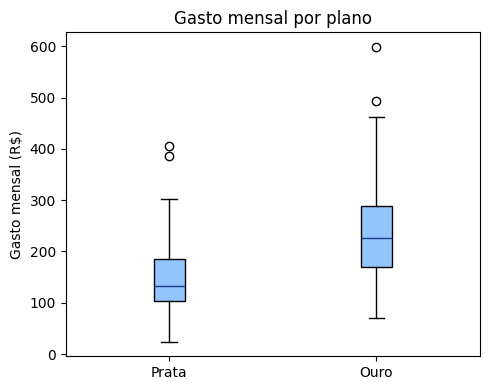

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([prata, ouro], tick_labels=["Prata", "Ouro"], patch_artist=True,
           boxprops=dict(facecolor="#93c5fd"), medianprops=dict(color="#1e3a8a"))
ax.set_ylabel("Gasto mensal (R$)")
ax.set_title("Gasto mensal por plano")
plt.tight_layout()
plt.show()

**Leitura do resultado:** a lógica do bloco de código é o fluxo que evita o erro mais comum em análise de dois grupos — rodar `ttest_ind` no piloto automático sem checar se a premissa de variância é razoável. Amostra pequena (n<30) e não-normal → Mann-Whitney (compara medianas/postos, não médias, e é robusto a outliers). Amostra normal com variâncias diferentes → Welch. Normal e variâncias parecidas → Student clássico.

**Decisão de negócio:** se a diferença for significativa e positiva pro Ouro, isso sustenta a precificação do plano (clientes de fato consomem/gastam mais) — mas não prova causalidade: talvez o cliente já gastasse mais **antes** de migrar pro Ouro (viés de seleção). Pra separar "o plano Ouro faz o cliente gastar mais" de "quem já gasta mais escolhe o Ouro", seria preciso um desenho pareado (ex: clientes que fizeram upgrade, gasto antes x depois — mesma lógica do Caso 2) ou um experimento controlado.

## Caso 4 — Churn: o programa de retenção reduziu a taxa de cancelamento?

**Contexto:** um grupo de clientes em risco recebeu uma ação de retenção (desconto, contato do CS) e outro grupo (igualmente em risco, não contatado — ou período anterior à ação) não recebeu. A pergunta é se a **taxa de churn** foi menor em quem recebeu a ação.

**Por que isso é o mesmo teste do Caso 1:** churn é uma variável binária (cancelou / não cancelou) igual conversão — a mecânica estatística é idêntica ao teste Z de duas proporções, só muda a direção que interessa (aqui, **taxa menor é melhor**).

**Hipóteses:**
- H0: a taxa de churn é igual nos dois grupos
- H1: as taxas são diferentes (aqui olhamos direção: queremos saber se `churn_tratado < churn_controle`)

In [6]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm

# --- Simula a base (troque por query: clientes em risco x receberam ação x cancelaram) ---
np.random.seed(13)
n_controle, n_tratado = 950, 980
churn_controle = np.random.binomial(1, 0.146, n_controle)   # sem ação de retenção: ~14,6% cancelam
churn_tratado = np.random.binomial(1, 0.112, n_tratado)     # com ação de retenção: ~11,2% cancelam

df = pd.concat([
    pd.DataFrame({"cliente_id": range(n_controle), "grupo": "sem_acao", "cancelou": churn_controle}),
    pd.DataFrame({"cliente_id": range(n_controle, n_controle + n_tratado), "grupo": "com_acao", "cancelou": churn_tratado}),
])

resumo = df.groupby("grupo")["cancelou"].agg(["sum", "count", "mean"]).rename(
    columns={"sum": "cancelamentos", "count": "clientes", "mean": "taxa_churn"}
)
print(resumo)

sucessos = np.array([resumo.loc["sem_acao", "cancelamentos"], resumo.loc["com_acao", "cancelamentos"]])
observacoes = np.array([resumo.loc["sem_acao", "clientes"], resumo.loc["com_acao", "clientes"]])

z_stat, p_value = proportions_ztest(sucessos, observacoes)

churn_sem = resumo.loc["sem_acao", "taxa_churn"]
churn_com = resumo.loc["com_acao", "taxa_churn"]
reducao_absoluta = churn_sem - churn_com
reducao_relativa = reducao_absoluta / churn_sem

confidence = 0.95
Z = norm.ppf((1 + confidence) / 2)
se = np.sqrt(churn_sem * (1 - churn_sem) / observacoes[0] + churn_com * (1 - churn_com) / observacoes[1])
ic_low, ic_high = reducao_absoluta - Z * se, reducao_absoluta + Z * se

print(f"\nChurn sem ação:        {churn_sem:.2%}")
print(f"Churn com ação:        {churn_com:.2%}")
print(f"Redução absoluta:      {reducao_absoluta:+.2%} pontos percentuais")
print(f"Redução relativa:      {reducao_relativa:+.1%}")
print(f"p-value:               {p_value:.4f}")
print(f"IC 95% da redução:     [{ic_low:.2%}, {ic_high:.2%}]")

alpha = 0.05
print(f"\nRedução estatisticamente significativa (alpha={alpha}): {p_value < alpha}")

clientes_retidos_estimado = reducao_absoluta * observacoes[1]
print(f"Clientes retidos estimados na base tratada: ~{clientes_retidos_estimado:.0f}")

          cancelamentos  clientes  taxa_churn
grupo                                        
com_acao            112       980    0.114286
sem_acao            141       950    0.148421

Churn sem ação:        14.84%
Churn com ação:        11.43%
Redução absoluta:      +3.41% pontos percentuais
Redução relativa:      +23.0%
p-value:               0.0263
IC 95% da redução:     [0.40%, 6.43%]

Redução estatisticamente significativa (alpha=0.05): True
Clientes retidos estimados na base tratada: ~33


**Leitura do resultado:** mesma régua do Caso 1 — p-value abaixo do alpha e IC que não cruza o zero indicam que a redução de churn é real, não sorte de amostra. Repare que aqui a leitura de negócio é invertida: **taxa menor é a vitória**, então o sinal da diferença que importa é `churn_sem_acao - churn_com_acao` positivo.

**Decisão de negócio:** `clientes_retidos_estimado` multiplicado pelo ticket médio/LTV desses clientes dá o valor financeiro da ação — compare com o custo do programa (desconto concedido, horas de CS) pra decidir se vale escalar pra toda a base em risco. Vale também rodar esse teste **por segmento** (ex: por plano, por tempo de casa) — uma ação pode funcionar bem em um segmento e não ter efeito em outro, e a média geral esconde isso.

## Caso 5 — Qui-quadrado: canal de aquisição influencia o plano contratado?

**Contexto:** o time de marketing quer saber se o **canal de aquisição** do cliente (Orgânico, Pago, Indicação) está associado ao **plano contratado** (Básico, Prata, Ouro) — ou seja, se clientes vindos de canais diferentes tendem a contratar planos diferentes.

**Por que qui-quadrado:** as duas variáveis são categóricas (não são números pra tirar média), então a pergunta não é "a média é diferente", é "a distribuição de planos é diferente entre canais". Isso é feito com uma tabela de contingência (canal x plano) e o teste qui-quadrado de independência.

**Hipóteses:**
- H0: canal de aquisição e plano contratado são independentes (a distribuição de planos é parecida em todos os canais)
- H1: existe associação entre as duas variáveis

**Cuidado:** o qui-quadrado exige frequência esperada ≥ 5 em cada célula da tabela pra ser confiável — o código checa isso antes de confiar no p-valor.

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# --- Simula a base de clientes (troque por query: canal_aquisicao, plano) ---
np.random.seed(4)
n = 1400
canal = np.random.choice(["Organico", "Pago", "Indicacao"], size=n, p=[0.45, 0.35, 0.20])

plano = []
for c in canal:
    if c == "Organico":
        probs = [0.55, 0.32, 0.13]   # tende mais pro plano básico
    elif c == "Pago":
        probs = [0.30, 0.40, 0.30]
    else:  # Indicacao
        probs = [0.20, 0.35, 0.45]   # tende mais pro plano ouro
    plano.append(np.random.choice(["Basico", "Prata", "Ouro"], p=probs))

df = pd.DataFrame({"canal_aquisicao": canal, "plano": plano})

# --- Tabela de contingência ---
tabela = pd.crosstab(df["canal_aquisicao"], df["plano"])
print("Tabela de contingência (contagens observadas):")
print(tabela)

chi2, p_value, dof, esperado = chi2_contingency(tabela)

print(f"\nQui-quadrado: {chi2:.2f}")
print(f"Graus de liberdade: {dof}")
print(f"p-value: {p_value:.6f}")

freq_min_esperada = esperado.min()
print(f"\nMenor frequência esperada: {freq_min_esperada:.1f} "
      f"({'OK, teste confiável' if freq_min_esperada >= 5 else 'ATENÇÃO: abaixo de 5, considerar agrupar categorias ou usar teste exato'})")

# --- Tamanho do efeito: V de Cramér (0=nenhuma associação, 1=associação perfeita) ---
n_obs = tabela.values.sum()
k = min(tabela.shape) - 1
cramers_v = np.sqrt((chi2 / n_obs) / k)

alpha = 0.05
print(f"\nAssociação estatisticamente significativa (alpha={alpha}): {p_value < alpha}")
print(f"V de Cramér: {cramers_v:.3f}")

# --- Distribuição percentual por canal, pra leitura de negócio ---
print("\nDistribuição de planos por canal (%):")
print((pd.crosstab(df["canal_aquisicao"], df["plano"], normalize="index") * 100).round(1))

Tabela de contingência (contagens observadas):
plano            Basico  Ouro  Prata
canal_aquisicao                     
Indicacao            65   125    100
Organico            337    86    204
Pago                140   162    181

Qui-quadrado: 147.68
Graus de liberdade: 4
p-value: 0.000000

Menor frequência esperada: 77.3 (OK, teste confiável)

Associação estatisticamente significativa (alpha=0.05): True
V de Cramér: 0.230

Distribuição de planos por canal (%):
plano            Basico  Ouro  Prata
canal_aquisicao                     
Indicacao          22.4  43.1   34.5
Organico           53.7  13.7   32.5
Pago               29.0  33.5   37.5


**Leitura do resultado:** p-value baixo → existe associação real entre canal e plano, não é coincidência de amostra. Mas o qui-quadrado **não diz o tamanho** da associação — é aí que entra o **V de Cramér**: perto de 0 é associação fraca (estatisticamente real, mas pouco útil pra decisão), perto de 1 é forte. Referência solta pra tabelas pequenas (poucos graus de liberdade): ~0,1 fraca, ~0,3 moderada, ~0,5+ forte.

**Decisão de negócio:** a tabela de percentuais por linha é o que vira ação — se Indicação traz proporcionalmente mais clientes Ouro, isso é argumento pra priorizar orçamento/incentivo de indicação em vez de mídia paga, se o objetivo for cliente de maior valor. Se alguma célula da tabela tiver frequência esperada abaixo de 5 (comum quando uma categoria é rara), agrupe categorias raras antes de confiar no p-valor, ou use o teste exato de Fisher para tabelas 2x2 (seção 6 do notebook anterior).

## Caso 6 — ANOVA: o ticket médio varia entre os canais de venda?

**Contexto:** a empresa vende por três canais — Site, App e Loja física — e você quer saber se o **ticket médio** difere entre eles. Com três grupos, rodar três t-tests par a par (Site x App, Site x Loja, App x Loja) infla o erro Tipo I acumulado; a ANOVA testa os três de uma vez.

**Hipóteses:**
- H0: o ticket médio é igual nos três canais
- H1: pelo menos um canal tem ticket médio diferente dos demais

**Limitação da ANOVA:** ela diz que existe diferença, mas não qual canal difere de qual — por isso o código roda o post-hoc de Tukey HSD em seguida, que já vem com correção pra múltiplas comparações embutida.

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- Simula os três canais (troque por query filtrando por canal_venda) ---
np.random.seed(15)
site = np.round(np.random.gamma(shape=5, scale=28, size=120), 2)
app = np.round(np.random.gamma(shape=5, scale=24, size=95), 2)
loja = np.round(np.random.gamma(shape=6, scale=33, size=80), 2)

df = pd.concat([
    pd.DataFrame({"canal": "Site", "ticket": site}),
    pd.DataFrame({"canal": "App", "ticket": app}),
    pd.DataFrame({"canal": "Loja", "ticket": loja}),
])

print(df.groupby("canal")["ticket"].agg(["count", "mean", "std"]).round(2))

alpha = 0.05

# --- Checagem de premissas (mesma lógica do Caso 3, agora pra 3 grupos) ---
p_shapiro = {c: shapiro(g).pvalue for c, g in [("Site", site), ("App", app), ("Loja", loja)]}
p_levene = levene(site, app, loja).pvalue
print(f"\nShapiro por canal: { {k: round(v, 4) for k, v in p_shapiro.items()} }")
print(f"Levene (variâncias entre os 3 grupos): p={p_levene:.4f}")

# --- ANOVA ---
F, p_value = f_oneway(site, app, loja)

grand_mean = np.concatenate([site, app, loja]).mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in (site, app, loja))
ss_total = sum(((g - grand_mean) ** 2).sum() for g in (site, app, loja))
eta_squared = ss_between / ss_total

print(f"\nEstatística F: {F:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"Eta²: {eta_squared:.3f} (proporção da variação do ticket explicada pelo canal)")
print(f"Diferença significativa entre pelo menos um par de canais (alpha={alpha}): {p_value < alpha}")

# --- Post-hoc Tukey: qual par difere ---
valores = np.concatenate([site, app, loja])
grupos = ["Site"] * len(site) + ["App"] * len(app) + ["Loja"] * len(loja)
tukey = pairwise_tukeyhsd(endog=valores, groups=grupos, alpha=alpha)
print("\nPost-hoc Tukey HSD:")
print(tukey)

       count    mean    std
canal                      
App       95  120.63  59.39
Loja      80  197.58  88.28
Site     120  133.45  59.62

Shapiro por canal: {'Site': np.float64(0.0002), 'App': np.float64(0.0002), 'Loja': np.float64(0.0005)}
Levene (variâncias entre os 3 grupos): p=0.0017

Estatística F: 31.190
p-value: 0.00000
Eta²: 0.176 (proporção da variação do ticket explicada pelo canal)
Diferença significativa entre pelo menos um par de canais (alpha=0.05): True



Post-hoc Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   App   Loja  76.9502    0.0  52.4622 101.4383   True
   App   Site  12.8196 0.3619  -9.3424  34.9816  False
  Loja   Site -64.1307    0.0 -87.4235 -40.8379   True
------------------------------------------------------


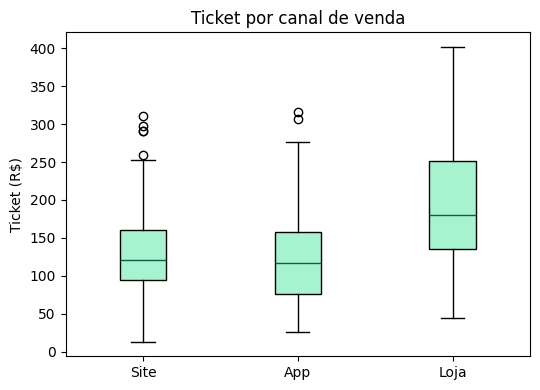

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.boxplot([site, app, loja], tick_labels=["Site", "App", "Loja"], patch_artist=True,
           boxprops=dict(facecolor="#a7f3d0"), medianprops=dict(color="#065f46"))
ax.set_ylabel("Ticket (R$)")
ax.set_title("Ticket por canal de venda")
plt.tight_layout()
plt.show()

**Leitura do resultado:** a ANOVA responde "existe diferença entre os canais?" — se p < alpha, sim. O `Eta²` diz **o quanto** o canal explica da variação total do ticket (ex: 0,08 = 8% da variação do ticket é explicada por qual canal o cliente comprou; o resto é variação individual). A tabela do Tukey mostra, par a par, quais canais realmente diferem entre si (`reject=True`) e a diferença de médias já com o intervalo de confiança ajustado.

**Decisão de negócio:** se Loja tiver ticket médio significativamente maior que Site e App (Tukey confirma o par), isso é argumento pra estratégias de upsell equivalentes nos canais digitais, ou pra investigar o que a experiência de loja física faz diferente (atendimento, combo de produtos). Se a ANOVA não for significativa, não faz sentido caçar diferença canal a canal — a variação observada nas médias é compatível com ruído amostral.

## Checklist final — qual teste usar no seu caso

| Você tem... | E quer comparar... | Use |
|---|---|---|
| Taxa de conversão/churn em 2 grupos independentes | Se a proporção difere | Teste Z de proporções (Casos 1 e 4) |
| Métrica contínua (ticket, tempo, nota) nos **mesmos** indivíduos em 2 momentos | Antes x depois | Teste t **pareado** (Caso 2) |
| Métrica contínua em 2 grupos de indivíduos **diferentes** | 2 grupos independentes | t de Student / Welch / Mann-Whitney, conforme premissas (Caso 3) |
| Duas variáveis categóricas (canal, categoria, plano, região) | Se estão associadas | Qui-quadrado de independência (Caso 5) |
| Métrica contínua em 3+ grupos independentes | Se pelo menos um grupo difere | ANOVA + post-hoc Tukey (Caso 6) |

**Lembretes que valem pra todos os casos:**
- Significância estatística (`p < alpha`) não é o mesmo que significância prática — sempre traduza o resultado pra uma métrica de negócio (R$, clientes, pontos percentuais) antes de decidir.
- p-value alto não prova que os grupos são iguais — pode ser só amostra pequena demais pra detectar a diferença (ver seções de tamanho de amostra no `stats_tests_resumo_1`).
- Sempre que possível, complemente o p-value com um intervalo de confiança e um tamanho de efeito (lift, Cohen's d/dz, Eta², V de Cramér) — eles dizem *o quanto* importa, não só *se* importa.